# Interest Rates vs Housing Starts

My project will look at whether higher interest rates are associated with lower housing market activity in the United States. I will use monthly data from the Federal Reserve Bank of St. Louis FRED database, including the federal funds rate.

My hypothesis is that months with higher interest rates will have lower average housing starts.

H0: There is no difference in average housing starts between high interest rate months and low interest rate months.

H1: Average housing starts are lower during high interest rate months than during low interest rate months.

In [5]:
import pandas as pd

fed = pd.read_csv("final project/FEDFUNDS.csv")
houst = pd.read_csv("final project/HOUST (1).csv")
mortgage = pd.read_csv("final project/MORTGAGE30US.csv")
permit = pd.read_csv("final project/PERMIT.csv")

In [8]:
print(fed.head())
print(houst.head())
print(mortgage.head())
print(permit.head())

  observation_date  FEDFUNDS
0       2000-03-01      5.85
1       2000-04-01      6.02
2       2000-05-01      6.27
3       2000-06-01      6.53
4       2000-07-01      6.54
  observation_date  HOUST
0       2000-01-01   1636
1       2000-02-01   1737
2       2000-03-01   1604
3       2000-04-01   1626
4       2000-05-01   1575
  observation_date  MORTGAGE30US
0       2000-01-07          8.15
1       2000-01-14          8.18
2       2000-01-21          8.26
3       2000-01-28          8.25
4       2000-02-04          8.25
  observation_date  PERMIT
0       2000-01-01    1727
1       2000-02-01    1692
2       2000-03-01    1651
3       2000-04-01    1597
4       2000-05-01    1543


In [11]:
fed = fed.rename(columns={"observation_date": "date"})
houst = houst.rename(columns={"observation_date": "date"})
mortgage = mortgage.rename(columns={"observation_date": "date"})
permit = permit.rename(columns={"observation_date": "date"})

In [12]:
fed["date"] = pd.to_datetime(fed["date"])
houst["date"] = pd.to_datetime(houst["date"])
mortgage["date"] = pd.to_datetime(mortgage["date"])
permit["date"] = pd.to_datetime(permit["date"])

In [14]:
fed.columns
fed.head()

,date,FEDFUNDS
0,2000-03-01,5.85
1,2000-04-01,6.02
2,2000-05-01,6.27
3,2000-06-01,6.53
4,2000-07-01,6.54


In [15]:
df = pd.merge(houst, fed, on="date")
df = pd.merge(df, permit, on="date")

In [16]:
df = df.rename(columns={
    "HOUST": "housing",
    "FEDFUNDS": "rate",
    "PERMIT": "permits"
})

In [18]:
df.head()
df.describe()

,date,housing,rate,permits
count,313,313.000000,313.000000,313.000000
mean,2013-03-01 19:37:45.814696,1306.386581,2.000543,1367.067093
min,2000-03-01 00:00:00,478.000000,0.050000,513.000000
25%,2006-09-01 00:00:00,1023.000000,0.150000,1072.000000
50%,2013-03-01 00:00:00,1324.000000,1.260000,1401.000000
75%,2019-09-01 00:00:00,1592.000000,3.880000,1659.000000
max,2026-03-01 00:00:00,2273.000000,6.540000,2263.000000
std,NaN,422.261685,2.014532,436.916415


In [20]:
median_rate = df["rate"].median()

df["rate_group"] = "Low"
df.loc[df["rate"] > median_rate, "rate_group"] = "High"

df.groupby("rate_group")["housing"].mean()

rate_group
High    1497.864516
Low     1118.544304
Name: housing, dtype: float64

## Results

The average housing starts during high interest rate periods is about 1498, while during low interest rate periods it is about 1119. 

This result is unexpected, because it suggests that housing starts are higher during periods of higher interest rates. This may be due to other economic factors influencing housing activity, or the timing of economic cycles. Further analysis is needed to better understand this.

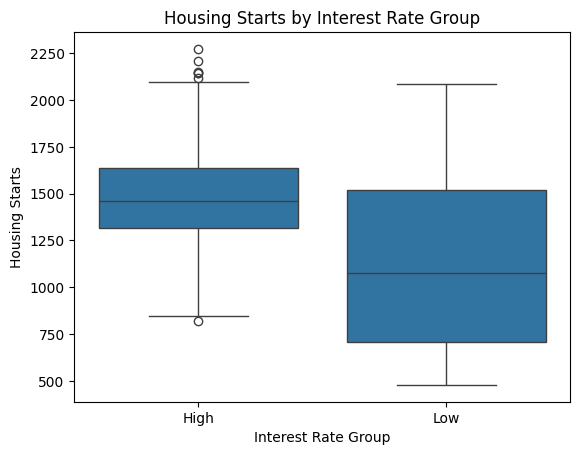

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="rate_group", y="housing", data=df)

plt.title("Housing Starts by Interest Rate Group")
plt.xlabel("Interest Rate Group")
plt.ylabel("Housing Starts")

plt.show()